# 1 Импорт библиотек и функций

## 1.1 Библиотеки

In [190]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from aiomoex import get_board_candles
import asyncio
import aiohttp
from statsmodels.graphics.tsaplots import plot_acf
import ta
from sklearn.ensemble import RandomForestRegressor
from typing import List, Dict
import os

## 1.2 Функции

In [193]:
def plot_close_and_target(df, ticker):
    """
    Строит два графика: close от даты и target_price_change от даты
    
    Args:
        df: DataFrame с колонками 'begin', 'close', 'target_price_change'
        ticker: название тикера для заголовка
    """
    # Конвертируем дату в datetime если нужно
    if df['begin'].dtype == 'object':
        df = df.copy()
        df['begin'] = pd.to_datetime(df['begin'])
    
    # Создаем фигуру с двумя subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # График 1: Close price
    ax1.plot(df['begin'], df['close'], linewidth=1, color='blue')
    ax1.set_title(f'{ticker} - Цена закрытия', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Цена (руб)', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    
    # График 2: Target price change
    ax2.plot(df['begin'], df['target_price_change'], linewidth=1, color='red')
    ax2.set_title(f'{ticker} - Изменение цены через 7 дней (%)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Изменение (%)', fontsize=12)
    ax2.set_xlabel('Дата', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)
    
    # Добавляем горизонтальную линию на нуле для второго графика
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    
    # Добавляем заливку для положительных и отрицательных значений
    ax2.fill_between(df['begin'], df['target_price_change'], 0, 
                    where=(df['target_price_change'] >= 0), 
                    color='green', alpha=0.3, label='Рост')
    ax2.fill_between(df['begin'], df['target_price_change'], 0, 
                    where=(df['target_price_change'] < 0), 
                    color='red', alpha=0.3, label='Падение')
    
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Выводим статистику
    print(f"Статистика для {ticker}:")
    print(f"Период: {df['begin'].min().strftime('%Y-%m-%d')} - {df['begin'].max().strftime('%Y-%m-%d')}")
    print(f"Количество дней: {len(df)}")
    print(f"Среднее изменение: {df['target_price_change'].mean():.2f}%")
    print(f"Максимальный рост: {df['target_price_change'].max():.2f}%")
    print(f"Максимальное падение: {df['target_price_change'].min():.2f}%")
    print(f"Волатильность (std): {df['target_price_change'].std():.2f}%")


In [195]:
def generate_features_optimized(stock_data: Dict[str, pd.DataFrame]) -> Dict[str, pd.DataFrame]:
    """
    Генерирует оптимизированный набор технических индикаторов для данных акций
    """
    
    processed_data = {}
    
    for ticker, df in stock_data.items():
        if df.empty:
            processed_data[ticker] = df
            continue
            
        df_processed = df.copy().sort_values('begin')
        
        # ===== СКОЛЬЗЯЩИЕ СРЕДНИЕ =====
        df_processed['MA_90'] = df_processed['close'].rolling(window=90).mean()
        
        # ===== RSI =====
        df_processed['RSI_14'] = ta.momentum.RSIIndicator(df_processed['close'], window=14).rsi()
        df_processed['RSI_90'] = ta.momentum.RSIIndicator(df_processed['close'], window=90).rsi()
        
        # ===== МОМЕНТУМ =====
        df_processed['MOM_10'] = ta.momentum.ROCIndicator(df_processed['close'], window=10).roc()
        
        # ===== ATR =====
        df_processed['ATR_14'] = ta.volatility.AverageTrueRange(
            df_processed['high'], df_processed['low'], df_processed['close'], window=14
        ).average_true_range()
        
        # ===== ВОЛАТИЛЬНОСТЬ =====
        returns = df_processed['close'].pct_change()
        df_processed['VOLATILITY_20'] = returns.rolling(window=20).std() * np.sqrt(252)
        df_processed['VOLATILITY_50'] = returns.rolling(window=50).std() * np.sqrt(252)
        
        # ===== ОБЪЕМ =====
        df_processed['VOLUME_RATIO_20'] = (
            df_processed['volume'] / df_processed['volume'].rolling(window=20).mean()
        )
        
        # ===== MACD =====
        macd = ta.trend.MACD(df_processed['close'])
        df_processed['MACD_SIGNAL'] = macd.macd_signal()
        df_processed['MACD_HISTOGRAM'] = macd.macd_diff()
        
        processed_data[ticker] = df_processed
    
    return processed_data

def add_targets(stock_data, horizon_days=7):
    """
    Добавляет целевые переменные для прогнозирования
    """
    
    for ticker, df in stock_data.items():
        if df.empty:
            continue
            
        df_sorted = df.sort_values('begin')
        
        # Создаем копию данных
        df_merged = df_sorted.copy()
        
        # Добавляем будущую дату (ровно +horizon_days дней)
        df_merged['future_date'] = df_merged['begin'] + pd.Timedelta(days=horizon_days)
        
        # Создаем словарь с ценами по датам
        price_dict = df_sorted.set_index('begin')['close'].to_dict()
        
        # Добавляем будущую цену по точному соответствию дат
        df_merged['future_price'] = df_merged['future_date'].map(price_dict)
        
        # Вычисляем целевые переменные
        df_merged['target_price_change'] = (
            (df_merged['future_price'] / df_merged['close'] - 1) * 100
        )
        
        df_merged['target_class'] = df_merged['target_price_change'].apply(
            lambda x: 'L' if x < -1 else ('H' if x > 1 else 'N')
        )
        
        # Удаляем временные колонки
        df_merged = df_merged.drop(['future_date', 'future_price'], axis=1)
        
        stock_data[ticker] = df_merged
    
    return stock_data
    
def clean_generated_features(stock_data):
    """Удаляет строки с пропусками после генерации признаков"""
    cleaned_data = {}
    
    for ticker, df in stock_data.items():
        df_clean = df.dropna().copy()
        cleaned_data[ticker] = df_clean
    
    return cleaned_data

def save_features_to_csv(stock_data: Dict[str, pd.DataFrame], save_dir: str = './features_data'):
    """
    Сохраняет данные со сгенерированными признаками в CSV файлы
    """
    
    # Создаем директорию если не существует
    os.makedirs(save_dir, exist_ok=True)
    
    # Сохраняем каждый датафрейм в отдельный файл
    for ticker, df in stock_data.items():
        if not df.empty:
            # Создаем копию датафрейма
            df_to_save = df.copy()
            
            # Убираем указанные признаки
            columns_to_drop = ['open', 'high', 'low', 'value', 'volume', 'ticker']
            
            # Удаляем только те столбцы, которые существуют в датафрейме
            existing_columns_to_drop = [col for col in columns_to_drop if col in df_to_save.columns]
            df_to_save = df_to_save.drop(columns=existing_columns_to_drop)
            
            filename = f"stocks_features_{ticker}.csv"
            filepath = os.path.join(save_dir, filename)
            
            df_to_save.to_csv(filepath, index=False, encoding='utf-8')
            print(f"✅ {ticker}: обработан и сохранен ({len(df)} строк), признаков: {len(df_to_save.columns)}")
        else:
            print(f"❌ {ticker}: не удалось обработать")

In [197]:
def process_and_save_features(data_path: str, tickers: List[str], horizon_days: int = 7, save_dir: str = './features_data', end_date: str = None):
    """
    Основная функция для обработки данных и генерации признаков
    
    Args:
        data_path: Путь к папке с данными
        tickers: Список тикеров для обработки
        horizon_days: Горизонт прогнозирования в днях
        save_dir: Директория для сохранения результатов
        end_date: Верхняя граница даты в формате 'YYYY-MM-DD' (например, '2025-10-01'). 
                 Если None - фильтрация не применяется
    """
    
    stock_data = {}
    
    # Загружаем данные из CSV файлов
    for ticker in tickers:
        filename = f"stocks_{ticker}.csv"
        filepath = os.path.join(data_path, filename)
        
        try:
            df = pd.read_csv(filepath)
            df['begin'] = pd.to_datetime(df['begin'])
            stock_data[ticker] = df
        except FileNotFoundError:
            print(f"⚠️ Файл не найден: {filepath}")
            stock_data[ticker] = pd.DataFrame()
        except Exception as e:
            print(f"❌ Ошибка загрузки {ticker}: {e}")
            stock_data[ticker] = pd.DataFrame()
    
    # Генерируем признаки
    stock_data = generate_features_optimized(stock_data)
    
    # Добавляем целевые переменные
    stock_data = add_targets(stock_data, horizon_days=horizon_days)
    
    # Очищаем данные от пропусков
    stock_data = clean_generated_features(stock_data)
    
    # Применяем фильтрацию по дате если указана end_date
    if end_date:
        end_date_dt = pd.to_datetime(end_date)
        filtered_stock_data = {}
        for ticker, df in stock_data.items():
            if not df.empty:
                filtered_df = df[df['begin'] < end_date_dt].copy()
                filtered_stock_data[ticker] = filtered_df
                print(f"📅 {ticker}: отфильтровано {len(df) - len(filtered_df)} строк, осталось {len(filtered_df)}")
            else:
                filtered_stock_data[ticker] = df
        stock_data = filtered_stock_data
    
    # Сохраняем результаты
    save_features_to_csv(stock_data, save_dir=save_dir)
    
    # Сводная статистика
    processed_tickers = [ticker for ticker, df in stock_data.items() if not df.empty]
    total_rows = sum(len(df) for df in stock_data.values() if not df.empty)
    
    print(f"\n📊 Обработка завершена! Обработано {len(processed_tickers)} акций, всего строк: {total_rows}")
    
    if end_date:
        print(f"📅 Данные отфильтрованы по дате: строго до {end_date}")
    
    return stock_data

In [199]:
VALID_INTERVALS = {
    1: 1,    # 1 минута
    10: 10,  # 10 минут
    60: 60,  # 1 час
    120: 120, # 2 часа
    240: 240, # 4 часа
    24: 24,   # 1 день
    7: 7,     # 1 неделя
    31: 31    # 1 месяц
}

In [201]:
async def get_moex_data(tickers: list[str], start_date: str, end_date: str, interval: int = 24) -> dict[str, pd.DataFrame]:
    if interval not in VALID_INTERVALS:
        raise ValueError(f"Неверный интервал. Допустимые значения: {list(VALID_INTERVALS.keys())}")
    
    async with aiohttp.ClientSession() as session:
        coros = [fetch_ticker_data(session, ticker, interval, start_date, end_date) for ticker in tickers]
        stock_data = await asyncio.gather(*coros)
    
    stock_data_dict = {k: v for d in stock_data for k, v in d.items()}
    return stock_data_dict

In [203]:
async def fetch_ticker_data(session: aiohttp.ClientSession, ticker: str, interval: int, start_date: str, end_date: str) -> dict[str, pd.DataFrame]:
    try:
        # Для интервалов 120 и 240 парсим с интервалом 60 минут
        actual_interval = interval
        if interval in [120, 240]:
            actual_interval = 60
            
        res = await get_board_candles(session, ticker, actual_interval, start_date, end_date)
        if res:
            df = pd.DataFrame(res)
            
            if 'end' in df.columns:
                df = df.drop('end', axis=1)
            
            df['begin'] = pd.to_datetime(df['begin'])
            
            # Агрегация для интервалов 120 и 240 минут
            if interval == 120:
                # Агрегируем в 2-часовые интервалы, исключая 9:00
                df = df[df['begin'].dt.time != pd.Timestamp('09:00:00').time()]
                df = _aggregate_to_2h(df)
                
            elif interval == 240:
                # Агрегируем в 4-часовые интервалы, исключая 9:00
                df = df[df['begin'].dt.time != pd.Timestamp('09:00:00').time()]
                df = _aggregate_to_4h(df)
            
            if interval in [24, 7, 31]:
                df['begin'] = df['begin'].dt.normalize()

            if 'begin' in df.columns:
                cols = ['begin'] + [col for col in df.columns if col != 'begin']
                df = df[cols]
            
            df['ticker'] = ticker
            return {ticker: df}
        else:
            return {ticker: pd.DataFrame()}
    except Exception as e:
        print(f'Ошибка парсинга. Не удалось получить данные для {ticker}, {e}')
        return {ticker: pd.DataFrame()}

def _aggregate_to_2h(df):
    """Агрегирует часовые данные в 2-часовые интервалы только для основной сессии"""
    df = df.sort_values('begin')
    
    # Ограничиваем основной торговой сессией (10:00-18:45)
    df = df[(df['begin'].dt.time >= pd.Timestamp('10:00:00').time()) & 
            (df['begin'].dt.time <= pd.Timestamp('18:45:00').time())]
    
    df['time_group'] = df['begin'].dt.floor('2h')  
    
    odd_hour_mask = df['time_group'].dt.hour % 2 == 1
    df.loc[odd_hour_mask, 'time_group'] = df.loc[odd_hour_mask, 'time_group'] - pd.Timedelta(hours=1)
    
    # Фильтруем только нужные интервалы (10:00, 12:00, 14:00, 16:00, 18:00)
    df = df[df['time_group'].dt.hour.isin([10, 12, 14, 16, 18])]
    
    aggregated = df.groupby('time_group').agg({
        'open': 'first',
        'close': 'last',
        'high': 'max',
        'low': 'min',
        'volume': 'sum',
        'value': 'sum'
    }).reset_index()
    
    aggregated = aggregated.rename(columns={'time_group': 'begin'})
    return aggregated

def _aggregate_to_4h(df):
    """Агрегирует часовые данные в 4-часовые интервалы только для основной сессии"""
    df = df.sort_values('begin')
    
    # Ограничиваем основной торговой сессией (10:00-18:45)
    df = df[(df['begin'].dt.time >= pd.Timestamp('10:00:00').time()) & 
            (df['begin'].dt.time <= pd.Timestamp('18:45:00').time())]
    
    df['time_group'] = df['begin'].dt.floor('4h')  
    
    # Корректируем группы чтобы они начинались с 10:00, 14:00, 18:00
    hour_mod = df['time_group'].dt.hour % 4
    df['time_group'] = df['time_group'] - pd.to_timedelta(hour_mod, unit='h')
    
    # Фильтруем только нужные интервалы (10:00, 14:00, 18:00)
    df = df[df['time_group'].dt.hour.isin([10, 14, 18])]
    
    aggregated = df.groupby('time_group').agg({
        'open': 'first',
        'close': 'last',
        'high': 'max',
        'low': 'min',
        'volume': 'sum',
        'value': 'sum'
    }).reset_index()
    
    aggregated = aggregated.rename(columns={'time_group': 'begin'})
    return aggregated

In [205]:
async def save_moex_data_to_csv(
    tickers: List[str],
    start_date: str = '2022-05-01',
    end_date: str = '2025-10-01', 
    interval: int = 24,
    save_dir: str = './data'
) -> None:
    """
    Сохраняет данные MOEX в CSV файлы
    
    Args:
        tickers: Список тикеров
        start_date: Начальная дата в формате 'YYYY-MM-DD'
        end_date: Конечная дата в формате 'YYYY-MM-DD'
        interval: Интервал данных (1, 10, 60, 24, 7, 31)
        save_dir: Директория для сохранения файлов
    """
    
    stock_data = await get_moex_data(
        tickers=tickers,
        start_date=start_date,
        end_date=end_date,
        interval=interval
    )
    
    os.makedirs(save_dir, exist_ok=True)
    
    for ticker, df in stock_data.items():
        if not df.empty:
            filename = f"stocks_{ticker}.csv"
            filepath = os.path.join(save_dir, filename)
            
            df.to_csv(filepath, index=False, encoding='utf-8')
            print(f"Данные для {ticker} сохранены в {filepath}")
        else:
            print(f"Нет данных для тикера {ticker}")

# 2 Подготовка данных

## 2.0 Список тикеров

In [209]:
tickers = [
    'SBER', 'TCSG', 'GAZP', 'LKOH', 'ROSN'
]

## 2.1 Парсинг и сохранение данных по c 2022-05-01

In [212]:
await save_moex_data_to_csv(
    tickers=tickers,
    start_date='2022-05-01',
    end_date='2025-10-15',
    interval=120,
    save_dir='../../data/stock_prices'  
)

Данные для SBER сохранены в ../../data/stock_prices\stocks_SBER.csv
Данные для TCSG сохранены в ../../data/stock_prices\stocks_TCSG.csv
Данные для GAZP сохранены в ../../data/stock_prices\stocks_GAZP.csv
Данные для LKOH сохранены в ../../data/stock_prices\stocks_LKOH.csv
Данные для ROSN сохранены в ../../data/stock_prices\stocks_ROSN.csv


### 2.1.1 Считывание и проверка

In [214]:
data_sber = pd.read_csv("../../data/stock_prices/stocks_SBER.csv")
data_sber.head(20)

,begin,open,close,high,low,volume,value,ticker
0,2022-05-04 10:00:00,129.10,123.95,131.50,123.60,31301400,3.977375e+09,SBER
1,2022-05-04 12:00:00,123.89,125.35,126.23,123.60,10077140,1.261006e+09,SBER
2,2022-05-04 14:00:00,125.35,124.46,125.55,123.70,10238470,1.274690e+09,SBER
3,2022-05-04 16:00:00,124.42,122.70,124.47,122.50,12391760,1.526890e+09,SBER
4,2022-05-04 18:00:00,122.70,123.20,123.30,122.67,3168670,3.897124e+08,SBER
5,2022-05-05 10:00:00,124.21,123.41,125.54,122.75,17941850,2.230188e+09,SBER
6,2022-05-05 12:00:00,123.46,124.51,124.90,123.00,8536190,1.058103e+09,SBER
7,2022-05-05 14:00:00,124.53,124.22,125.09,123.88,7332840,9.122096e+08,SBER
8,2022-05-05 16:00:00,124.20,124.29,124.97,123.92,5502750,6.842800e+08,SBER
9,2022-05-05 18:00:00,124.30,124.80,124.80,124.25,2989720,3.720504e+08,SBER


In [215]:
data_sber.shape

(4642, 8)

In [216]:
pd.to_datetime(data_sber['begin']).dt.hour.unique()

array([10, 12, 14, 16, 18])

In [217]:
data_sber.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4642 entries, 0 to 4641
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   begin   4642 non-null   object 
 1   open    4642 non-null   float64
 2   close   4642 non-null   float64
 3   high    4642 non-null   float64
 4   low     4642 non-null   float64
 5   volume  4642 non-null   int64  
 6   value   4642 non-null   float64
 7   ticker  4642 non-null   object 
dtypes: float64(5), int64(1), object(2)
memory usage: 290.3+ KB


## 2.2 Генерация признаков и сохранение 

In [224]:
stock_data = process_and_save_features(
    data_path='../../data/stock_prices',  
    tickers=tickers,          
    horizon_days=7,           
    save_dir='../../data/stock_features_data',
    end_date="2025-10-01"
)

📅 SBER: отфильтровано 40 строк, осталось 4284
📅 TCSG: отфильтровано 0 строк, осталось 2959
📅 GAZP: отфильтровано 40 строк, осталось 4284
📅 LKOH: отфильтровано 40 строк, осталось 4284
📅 ROSN: отфильтровано 40 строк, осталось 4284
✅ SBER: обработан и сохранен (4284 строк), признаков: 14
✅ TCSG: обработан и сохранен (2959 строк), признаков: 14
✅ GAZP: обработан и сохранен (4284 строк), признаков: 14
✅ LKOH: обработан и сохранен (4284 строк), признаков: 14
✅ ROSN: обработан и сохранен (4284 строк), признаков: 14

📊 Обработка завершена! Обработано 5 акций, всего строк: 20095
📅 Данные отфильтрованы по дате: строго до 2025-10-01


### 2.2.1 Считвание и проверка

In [144]:
data_features_sber = pd.read_csv("../../data/stock_features_data/stocks_features_SBER.csv")
data_features_sber.head(10)

,begin,close,MA_90,RSI_14,RSI_90,MOM_10,ATR_14,VOLATILITY_20,VOLATILITY_50,VOLUME_RATIO_20,MACD_SIGNAL,MACD_HISTOGRAM,future_date,future_price,target_price_change,target_class
0,2022-05-31 18:00:00,118.30,122.841000,33.451702,44.649570,-2.408843,1.386295,0.090732,0.145286,0.333074,-0.737730,-0.311272,2022-06-07 18:00:00,118.32,0.016906,N
1,2022-06-01 10:00:00,121.14,122.809778,50.438362,47.959730,-0.402861,1.605131,0.129688,0.143645,2.782228,-0.765329,-0.110396,2022-06-08 10:00:00,121.33,0.156843,N
2,2022-06-01 12:00:00,121.60,122.768111,52.550987,48.464537,0.074068,1.569050,0.123915,0.143196,0.886712,-0.750921,0.057630,2022-06-08 12:00:00,120.65,-0.781250,N
3,2022-06-01 14:00:00,121.90,122.739667,53.930230,48.792134,0.585857,1.506975,0.124232,0.142827,1.123434,-0.704442,0.185915,2022-06-08 14:00:00,120.34,-1.279737,L
4,2022-06-01 16:00:00,122.04,122.732333,54.593550,48.945288,0.452712,1.483620,0.123295,0.135467,1.299372,-0.636459,0.271933,2022-06-08 16:00:00,119.98,-1.687971,L
5,2022-06-01 18:00:00,121.97,122.718667,54.173551,48.871384,1.077318,1.404790,0.123208,0.133996,0.380121,-0.558227,0.312927,2022-06-08 18:00:00,119.90,-1.697139,L
6,2022-06-02 10:00:00,119.47,122.674889,41.804046,46.344141,0.835584,1.516591,0.140677,0.141334,3.033036,-0.516287,0.167763,2022-06-09 10:00:00,118.38,-0.912363,N
7,2022-06-02 12:00:00,120.05,122.625333,44.944814,46.987291,1.359338,1.503263,0.141926,0.141752,1.107930,-0.488861,0.109703,2022-06-09 12:00:00,118.36,-1.407747,L
8,2022-06-02 14:00:00,119.21,122.569667,41.455343,46.176663,0.184889,1.470887,0.143386,0.142422,0.957149,-0.484258,0.018411,2022-06-09 14:00:00,118.12,-0.914353,N
9,2022-06-02 16:00:00,118.64,122.506889,39.229604,45.636405,-0.344393,1.428681,0.143621,0.142321,0.794642,-0.502192,-0.071735,2022-06-09 16:00:00,118.21,-0.362441,N


In [279]:
data_features_sber.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4284 entries, 0 to 4283
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   begin                4284 non-null   object 
 1   close                4284 non-null   float64
 2   MA_90                4284 non-null   float64
 3   RSI_14               4284 non-null   float64
 4   RSI_90               4284 non-null   float64
 5   MOM_10               4284 non-null   float64
 6   ATR_14               4284 non-null   float64
 7   VOLATILITY_20        4284 non-null   float64
 8   VOLATILITY_50        4284 non-null   float64
 9   VOLUME_RATIO_20      4284 non-null   float64
 10  MACD_SIGNAL          4284 non-null   float64
 11  MACD_HISTOGRAM       4284 non-null   float64
 12  target_price_change  4284 non-null   float64
 13  target_class         4284 non-null   object 
dtypes: float64(12), object(2)
memory usage: 468.7+ KB


In [220]:
data_features_sber.target_price_change.describe()

count    4284.000000
mean        0.512234
std         3.941899
min       -20.327916
25%        -1.514025
50%         0.367349
75%         2.353002
max        20.059442
Name: target_price_change, dtype: float64

<Axes: >

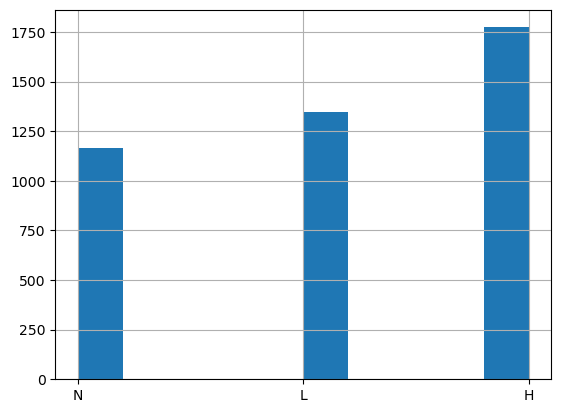

In [222]:
data_features_sber.target_class.hist()

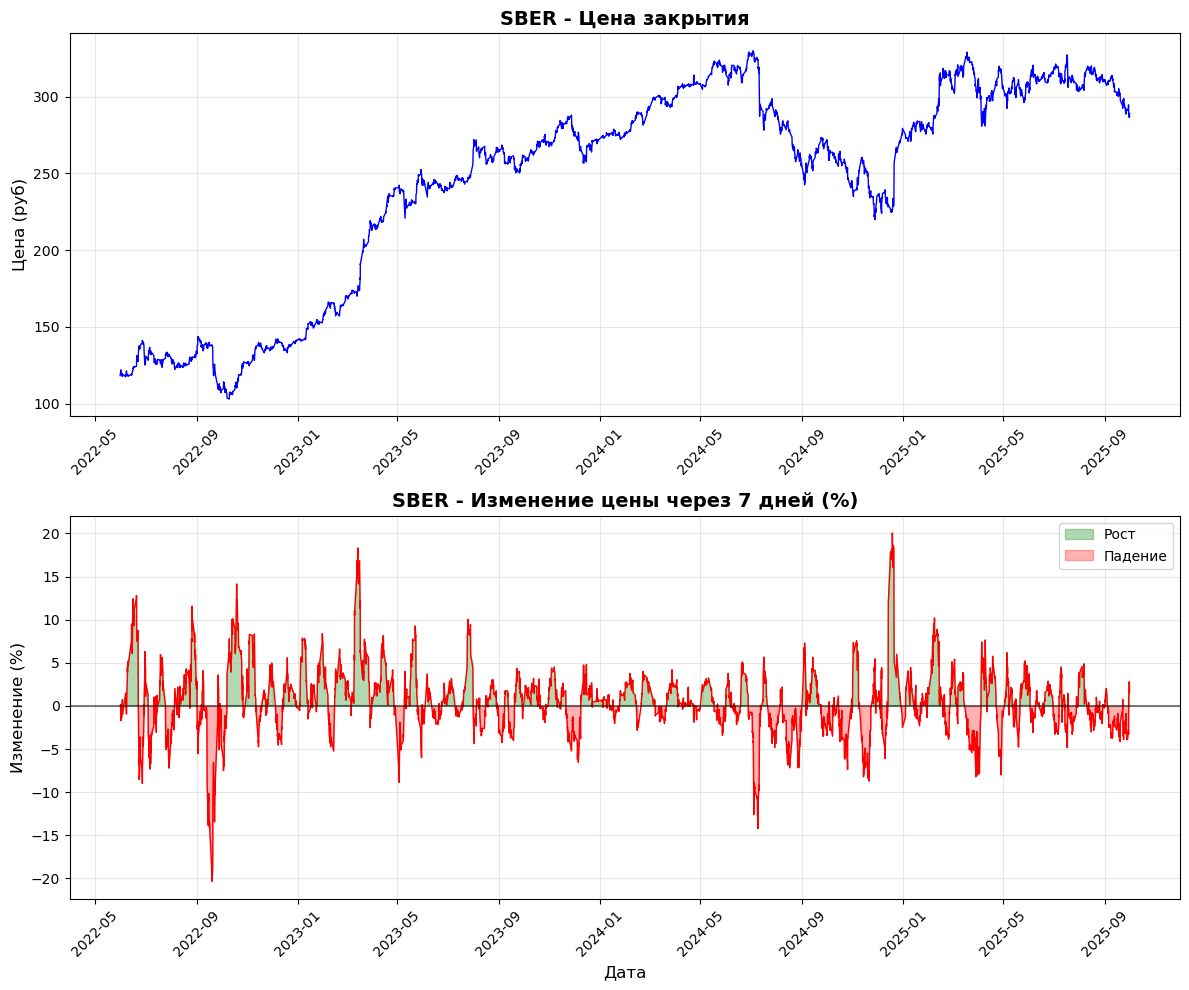

Статистика для SBER:
Период: 2022-05-31 - 2025-09-30
Количество дней: 4284
Среднее изменение: 0.51%
Максимальный рост: 20.06%
Максимальное падение: -20.33%
Волатильность (std): 3.94%


In [224]:
plot_close_and_target(data_features_sber, 'SBER')

In [225]:
data_features_sber['target_price_change'].mean()

0.5122339921367971

In [235]:
data_features_sber['target_price_change'].abs().mean()

2.7802037987932913

In [237]:
data_features_sber['target_price_change']

0       0.016906
1       0.156843
2      -0.781250
3      -1.279737
4      -1.687971
          ...   
4279    2.798202
4280    2.626635
4281    2.670157
4282    1.637245
4283    1.563202
Name: target_price_change, Length: 4284, dtype: float64

### 2.2.2 Проверка объединения при формировании целеового признака

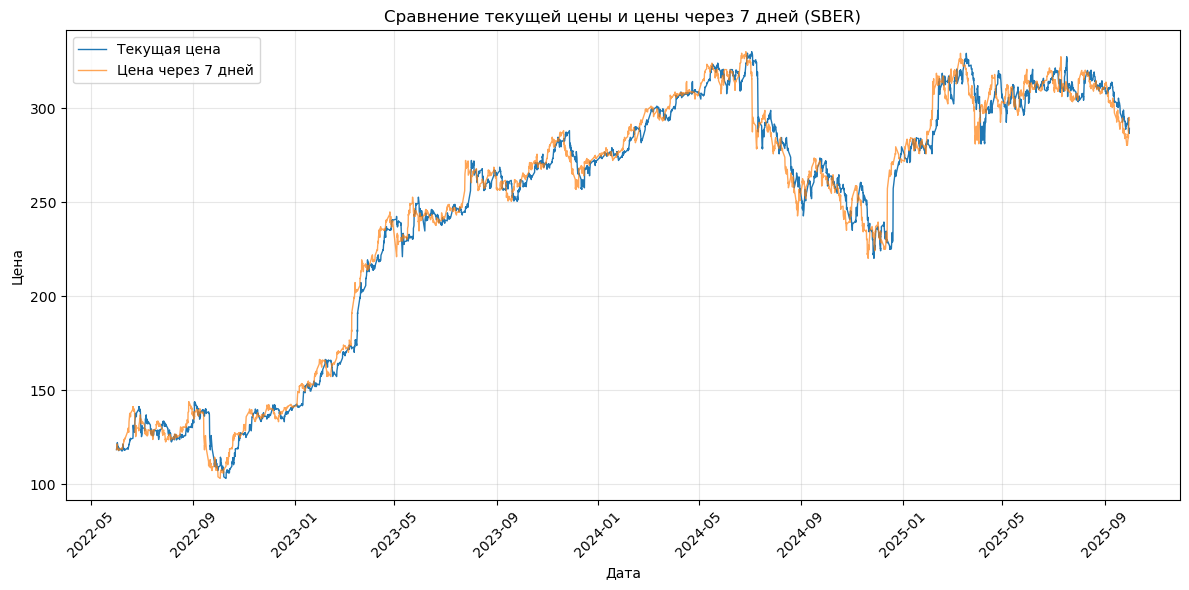

In [184]:
data_features_sber['begin'] = pd.to_datetime(data_features_sber['begin'])
#data_features_sber['future_date'] = pd.to_datetime(data_features_sber['future_date'])

# Построение графика
plt.figure(figsize=(12, 6))
plt.plot(data_features_sber['begin'], data_features_sber['close'], label='Текущая цена', linewidth=1)
plt.plot(data_features_sber['begin'], data_features_sber['future_price'], label='Цена через 7 дней', linewidth=1, alpha=0.7)

# Настройки графика
plt.title('Сравнение текущей цены и цены через 7 дней (SBER)')
plt.xlabel('Дата')
plt.ylabel('Цена')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [70]:
df_merged.iloc[:5]

,begin,close,future_date,future_price
0,2022-05-04 10:00:00,123.95,2022-05-11 10:00:00,124.31
1,2022-05-04 12:00:00,125.35,2022-05-11 12:00:00,123.95
2,2022-05-04 14:00:00,124.46,2022-05-11 14:00:00,122.70
3,2022-05-04 16:00:00,122.70,2022-05-11 16:00:00,123.17
4,2022-05-04 18:00:00,123.20,2022-05-11 18:00:00,123.34


In [80]:
df_merged.iloc[15:20]

,begin,close,future_date,future_price
15,2022-05-11 10:00:00,124.31,2022-05-18 10:00:00,131.04
16,2022-05-11 12:00:00,123.95,2022-05-18 12:00:00,129.91
17,2022-05-11 14:00:00,122.70,2022-05-18 14:00:00,129.00
18,2022-05-11 16:00:00,123.17,2022-05-18 16:00:00,126.30
19,2022-05-11 18:00:00,123.34,2022-05-18 18:00:00,125.12


### 2.2.3 Проверка

In [148]:
test_f = data_features_sber.copy()[['begin', 'close', 'future_date', 'future_price']]

In [150]:
test = data_sber.copy()[['begin', 'close']]
test['begin'] = pd.to_datetime(test['begin'])
test.head(2)

,begin,close
0,2022-05-04 10:00:00,123.95
1,2022-05-04 12:00:00,125.35


In [152]:
test['future_date'] = test['begin'] + pd.Timedelta(days=7)
print(test.shape)
test.head(2)

(4642, 3)


,begin,close,future_date
0,2022-05-04 10:00:00,123.95,2022-05-11 10:00:00
1,2022-05-04 12:00:00,125.35,2022-05-11 12:00:00


In [154]:
price_dict = test.set_index('begin')['close'].to_dict()

In [156]:
test['future_price'] = test['future_date'].map(price_dict)
print(test.shape)
test.head(2)

(4642, 4)


,begin,close,future_date,future_price
0,2022-05-04 10:00:00,123.95,2022-05-11 10:00:00,124.31
1,2022-05-04 12:00:00,125.35,2022-05-11 12:00:00,123.95


In [158]:
test.head(5)

,begin,close,future_date,future_price
0,2022-05-04 10:00:00,123.95,2022-05-11 10:00:00,124.31
1,2022-05-04 12:00:00,125.35,2022-05-11 12:00:00,123.95
2,2022-05-04 14:00:00,124.46,2022-05-11 14:00:00,122.70
3,2022-05-04 16:00:00,122.70,2022-05-11 16:00:00,123.17
4,2022-05-04 18:00:00,123.20,2022-05-11 18:00:00,123.34


In [170]:
test[test['begin'] >= '2022-05-11'].head(5)

,begin,close,future_date,future_price
15,2022-05-11 10:00:00,124.31,2022-05-18 10:00:00,131.04
16,2022-05-11 12:00:00,123.95,2022-05-18 12:00:00,129.91
17,2022-05-11 14:00:00,122.70,2022-05-18 14:00:00,129.00
18,2022-05-11 16:00:00,123.17,2022-05-18 16:00:00,126.30
19,2022-05-11 18:00:00,123.34,2022-05-18 18:00:00,125.12


In [172]:
test_f.head(5)

,begin,close,future_date,future_price
0,2022-05-31 18:00:00,118.30,2022-06-07 18:00:00,118.32
1,2022-06-01 10:00:00,121.14,2022-06-08 10:00:00,121.33
2,2022-06-01 12:00:00,121.60,2022-06-08 12:00:00,120.65
3,2022-06-01 14:00:00,121.90,2022-06-08 14:00:00,120.34
4,2022-06-01 16:00:00,122.04,2022-06-08 16:00:00,119.98


In [176]:
test_f[test_f['begin'] >= '2022-06-07 18:00:00'].head(5)

,begin,close,future_date,future_price
20,2022-06-07 18:00:00,118.32,2022-06-14 18:00:00,118.98
21,2022-06-08 10:00:00,121.33,2022-06-15 10:00:00,120.21
22,2022-06-08 12:00:00,120.65,2022-06-15 12:00:00,120.40
23,2022-06-08 14:00:00,120.34,2022-06-15 14:00:00,121.02
24,2022-06-08 16:00:00,119.98,2022-06-15 16:00:00,120.96


In [188]:
data_features_sber[['begin', 'close', 'future_date', 'future_price', 'target_price_change']]

,begin,close,future_date,future_price,target_price_change
0,2022-05-31 18:00:00,118.30,2022-06-07 18:00:00,118.32,0.016906
1,2022-06-01 10:00:00,121.14,2022-06-08 10:00:00,121.33,0.156843
2,2022-06-01 12:00:00,121.60,2022-06-08 12:00:00,120.65,-0.781250
3,2022-06-01 14:00:00,121.90,2022-06-08 14:00:00,120.34,-1.279737
4,2022-06-01 16:00:00,122.04,2022-06-08 16:00:00,119.98,-1.687971
...,...,...,...,...,...
4279,2025-09-30 10:00:00,286.97,2025-10-07 10:00:00,295.00,2.798202
4280,2025-09-30 12:00:00,287.44,2025-10-07 12:00:00,294.99,2.626635
4281,2025-09-30 14:00:00,286.50,2025-10-07 14:00:00,294.15,2.670157
4282,2025-09-30 16:00:00,288.90,2025-10-07 16:00:00,293.63,1.637245
